## PREDICTING H1N1 AND SEASONAL FLU VACCINES- PHASE 3 PROJECT

### PROJECT OVERVIEW

Vaccinations play a critical role in controlling infectious diseases by protecting individuals and contributing to herd immunity, making it an essential area of study in public health. This project focuses on predicting whether individuals received the H1N1 and seasonal vaccines using demographic, behavioral, and attitudinal data collected during the 2009 H1N1 flu pandemic.
 Using machine learning models, the analysis identifies key factors that influence vaccination decisions and estimates the likelihood of vaccine uptake. The insights gained can help improve public health strategies and guide more effective responses to future infectious disease outbreaks.

### BUSINESS PROBLEM

Public health organizations often face challenges in achieving high vaccination rates due to differences in individuals’ beliefs, behaviors, and access to healthcare. Without a clear understanding of these factors, it is difficult to design effective vaccination campaigns and allocate resources efficiently.

The goal of this project is to predict the likelihood that individuals received the H1N1 and seasonal flu vaccines, by estimating two probabilities: one for h1n1_vaccine and one for seasonal_vaccine. By identifying individuals who were less likely to have been vaccinated and understanding the factors influencing their decisions, stakeholders can implement targeted interventions, improve vaccine uptake, and reduce the spread of infectious diseases.

#### Project stakeholders
The stakeholders include:
1. Public Health Agencies: Tasked to gather insights to design vaccination
                             campaigns and policies.
2. Healthcare providers: Concerned with identifying and encouraging patients who are
                          less likely to get vaccinated.
3. Researchers & Data Scientists: Tasked to analyze trends and 
                                     improve predictive health models.



## BUSINESS UNDERSTANDING

The main objective and challenge is to predict how likely individuals received either or both of their two vaccines:

•	H1N1 vaccine

•	Seasonal flu vaccine

Specifically, the model must output:

•	Probability of receiving h1n1_vaccine

•	Probability of receiving seasonal_vaccine

•   Probability of receiving both of the vaccines


This enables better targeting of interventions and efficient allocation of public health resources.

### Objectives

1. Identify which vaccine has been effective.
2. Predict vaccination probabilities for each individual.
3. Identify key factors influencing vaccine uptake.
4. Improve decision-making for public health campaigns.


### KEY QUESTIONS
1. What are the key factors affecting vaccine uptake?
2. What is the probability that individuals got the two vaccines?
3. Probability that individuals got either of the vaccines?
4. What is the probability that individuals did not get either of the vaccines?
5. What vaccine has been effective? 







________________________________________





## DATA UNDERSTANDING

The dataset consists of 26,707 records, representing survey responses during the 2009 H1N1 pandemic. There are 36 features categorized into three main types:

•	Behavioral Features: Protective measures taken like behavioral_wash_hands and behavioral_face_mask.

•	Demographic Features: Personal information like age_group, education, race, sex.

•	Attitudinal Features: Beliefs about the flu and the vaccines like opinion_h1n1_risk, opinion_h1n1_vacc_effective.

My Target Variables: The two binary labels we want to predict: h1n1_vaccine and seasonal_vaccine.


### DATA LOADING AND PREPARATION

#### Importing important Libraries

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [94]:
y_train = pd.read_csv('training_set_labels.csv')
y_train

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0
...,...,...,...
26702,26702,0,0
26703,26703,0,0
26704,26704,0,1
26705,26705,0,0


In [95]:
vaccine_df_X_train = pd.read_csv('training_set_features.csv')
vaccine_df_X_test = pd.read_csv('test_set_features.csv')

In [96]:
vaccine_df_X_train.head

<bound method NDFrame.head of        respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
0                  0           1.0             0.0                        0.0   
1                  1           3.0             2.0                        0.0   
2                  2           1.0             1.0                        0.0   
3                  3           1.0             1.0                        0.0   
4                  4           2.0             1.0                        0.0   
...              ...           ...             ...                        ...   
26702          26702           2.0             0.0                        0.0   
26703          26703           1.0             2.0                        0.0   
26704          26704           2.0             2.0                        0.0   
26705          26705           1.0             1.0                        0.0   
26706          26706           0.0             0.0                        0.0  

#### Merging my datasets to one dataframe
To avoid data leakage I will merge this 2 datasets to split again. I will not use the test_set
 feature.csv

In [97]:

new_merged_dataset = vaccine_df_X_train.merge(y_train, on = 'respondent_id')
new_merged_dataset.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


### EXPLORING AND FAMILIARIZING WITH THE DATA(EDA)

In [98]:
new_merged_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

In [99]:
new_merged_dataset.columns

Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='object')

In [100]:
new_merged_dataset.shape

(26707, 38)

In [101]:
new_merged_dataset.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,...,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,...,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,...,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,...,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,...,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000


#### MISSING VALUES
Columns with high percentage of missing values are dropped since they are irrelevant to my analysis.

In [102]:
missing = new_merged_dataset.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(new_merged_dataset) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
employment_occupation,13470,50.44
employment_industry,13330,49.91
health_insurance,12274,45.96
income_poverty,4423,16.56
doctor_recc_seasonal,2160,8.09
doctor_recc_h1n1,2160,8.09
rent_or_own,2042,7.65
employment_status,1463,5.48
marital_status,1408,5.27
education,1407,5.27


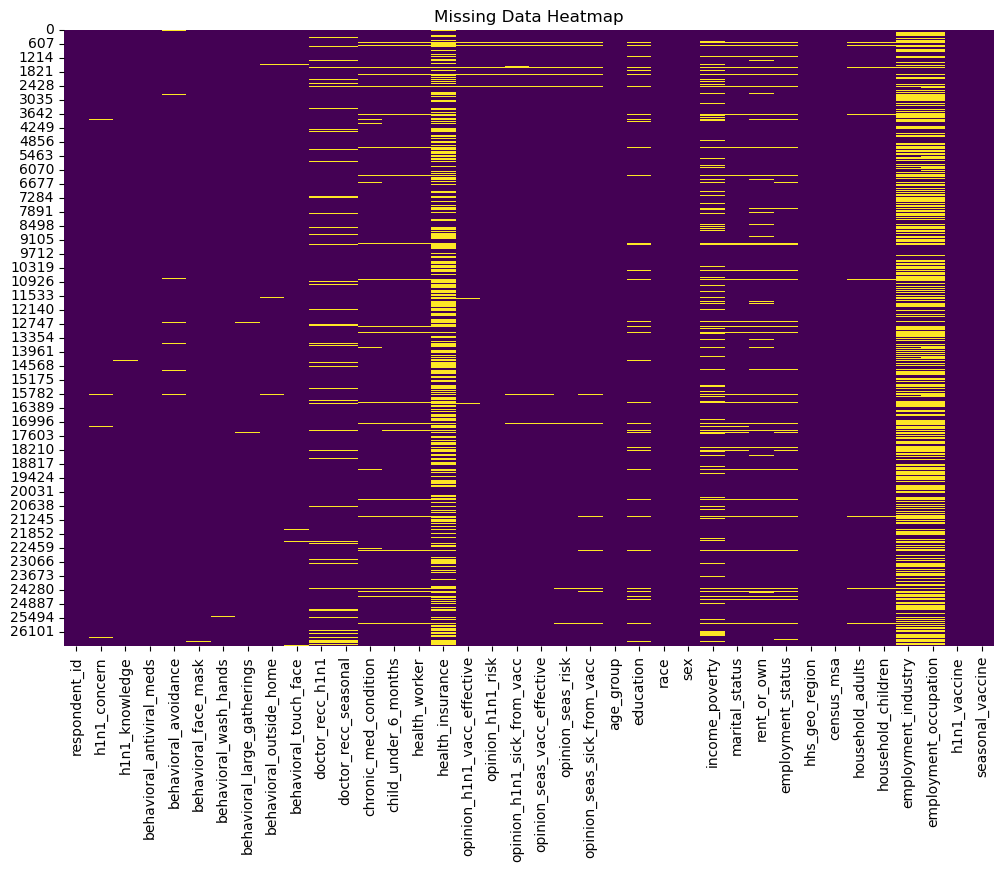

In [103]:
plt.figure(figsize=(12, 8))

# Missing Data Heatmap
sns.heatmap(new_merged_dataset.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

In [104]:
new_merged_dataset.isna().sum()

respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty                  4423
m

In [105]:
new_merged_dataset.duplicated().sum()

np.int64(0)

### Correlation — Numeric Features vs Targets

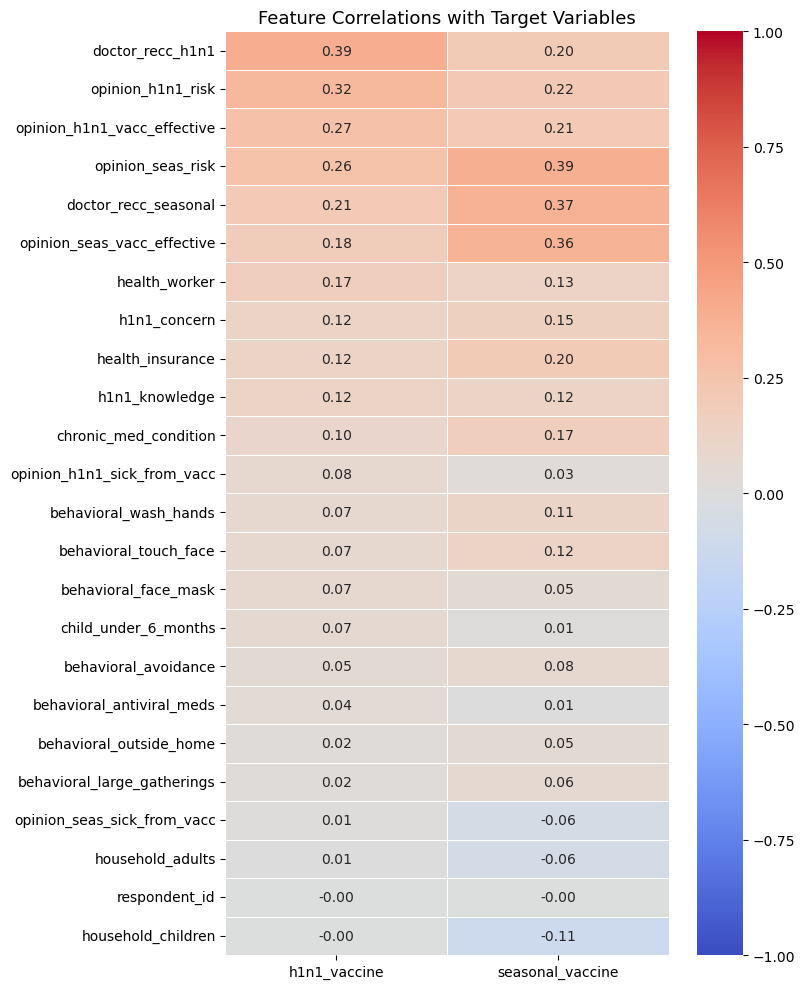

In [106]:
num_df = new_merged_dataset.select_dtypes(include='number')
corr_with_targets = num_df.corr()[['h1n1_vaccine', 'seasonal_vaccine']].drop(
    ['h1n1_vaccine', 'seasonal_vaccine']
).sort_values('h1n1_vaccine', ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(corr_with_targets, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlations with Target Variables', fontsize=13)
plt.tight_layout()
plt.show()

### Categorical Features — Vaccine Uptake by Group

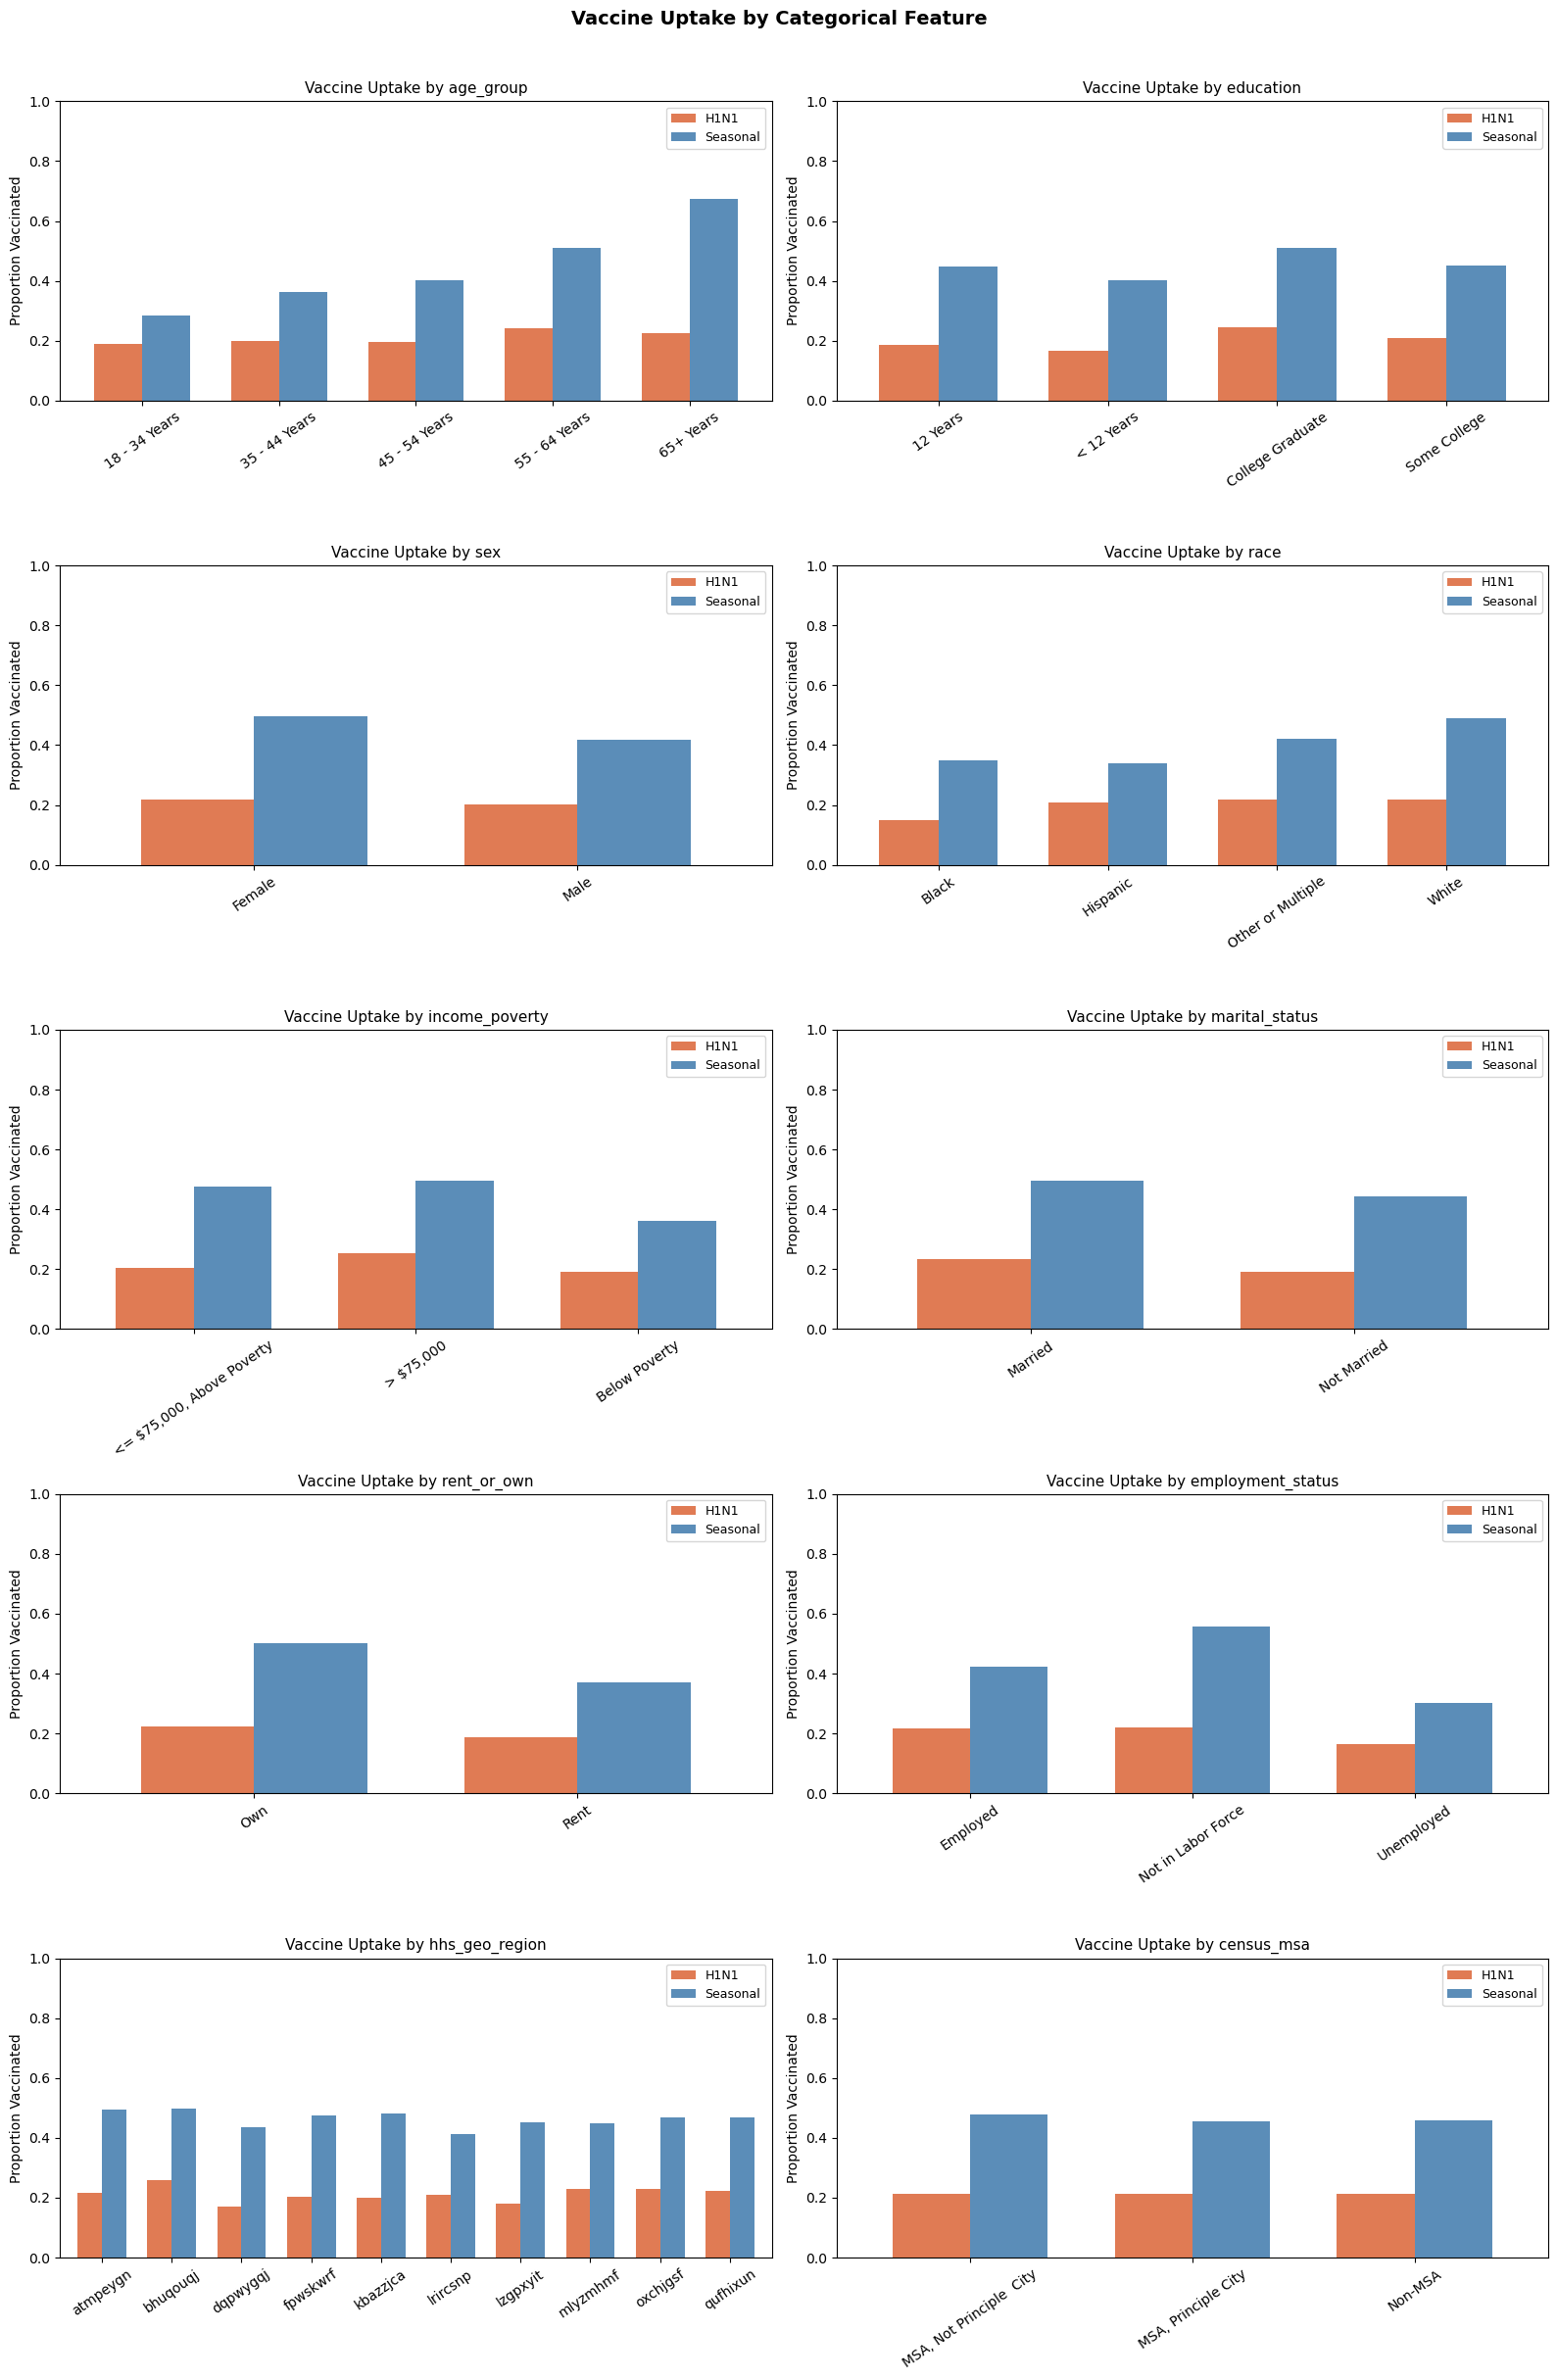

In [107]:
cat_features = [
    'age_group', 'education', 'sex', 'race',
    'income_poverty', 'marital_status', 'rent_or_own',
    'employment_status', 'hhs_geo_region', 'census_msa'
]

fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    uptake = new_merged_dataset.groupby(col)[['h1n1_vaccine', 'seasonal_vaccine']].mean()
    uptake.plot(kind='bar', ax=axes[i], color=['#e07b54', '#5b8db8'], width=0.7)
    axes[i].set_title(f'Vaccine Uptake by {col}', fontsize=11)
    axes[i].set_ylabel('Proportion Vaccinated')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].legend(['H1N1', 'Seasonal'], fontsize=9)
    axes[i].set_ylim(0, 1)

plt.suptitle('Vaccine Uptake by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### GROUPING WHO GOT EITHER VACCINES, NONE, OR BOTH

In [109]:
def vaccine_group(row):
    if row['h1n1_vaccine'] == 1 and row['seasonal_vaccine'] == 1:
        return 'Both Vaccines'
    elif row['h1n1_vaccine'] == 1 and row['seasonal_vaccine'] == 0:
        return 'H1N1 Only'
    elif row['h1n1_vaccine'] == 0 and row['seasonal_vaccine'] == 1:
        return 'Seasonal Only'
    else:
        return 'Neither Vaccine'
new_merged_dataset['vaccine_group'] = new_merged_dataset.apply(vaccine_group, axis=1)

In [110]:
# Count and percentage
group_counts = new_merged_dataset['vaccine_group'].value_counts()
group_pct    = (group_counts / len(new_merged_dataset) * 100).round(1)
print(pd.DataFrame({'Count': group_counts, '%': group_pct}))

                 Count     %
vaccine_group               
Neither Vaccine  13295  49.8
Seasonal Only     7738  29.0
Both Vaccines     4697  17.6
H1N1 Only          977   3.7


### Defining my X and Y variables

In [111]:
X = new_merged_dataset.drop(['seasonal_vaccine','h1n1_vaccine'], axis=1)
y = new_merged_dataset[['seasonal_vaccine','h1n1_vaccine']]

### SPLITTING MY DATA 

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [113]:
X_train.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,vaccine_group
24706,24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Married,Rent,Unemployed,lzgpxyit,"MSA, Not Principle City",1.0,0.0,NaN,NaN,Neither Vaccine
5393,5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,Not Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",0.0,0.0,wxleyezf,emcorrxb,Seasonal Only
20898,20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,Married,NaN,Employed,qufhixun,"MSA, Not Principle City",1.0,1.0,xicduogh,xtkaffoo,Both Vaccines
3429,3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Not Married,Own,Employed,bhuqouqj,Non-MSA,0.0,0.0,cfqqtusy,ukymxvdu,Neither Vaccine
8731,8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,Not Married,Own,Not in Labor Force,mlyzmhmf,"MSA, Principle City",1.0,1.0,NaN,NaN,Neither Vaccine


In [114]:
y_train.head()

,seasonal_vaccine,h1n1_vaccine
24706,0,0
5393,1,0
20898,1,1
3429,0,0
8731,0,0


In [115]:
X_test.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,vaccine_group
15772,15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,atmpeygn,"MSA, Principle City",NaN,NaN,NaN,NaN,Neither Vaccine
9407,9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,fpwskwrf,"MSA, Principle City",1.0,1.0,NaN,NaN,Seasonal Only
16515,16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Not Married,Own,Employed,atmpeygn,"MSA, Not Principle City",0.0,1.0,mfikgejo,mxkfnird,Neither Vaccine
23353,23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Married,Own,Employed,bhuqouqj,Non-MSA,1.0,2.0,cfqqtusy,xtkaffoo,Neither Vaccine
10008,10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Married,Own,Employed,lrircsnp,"MSA, Principle City",1.0,0.0,wxleyezf,xtkaffoo,Neither Vaccine


#### EXPLORING MY SPLIT DATA

#### FOR X_TRAIN

In [116]:
X_train.info()



<class 'pandas.core.frame.DataFrame'>
Index: 21365 entries, 24706 to 23654
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                21365 non-null  int64  
 1   h1n1_concern                 21292 non-null  float64
 2   h1n1_knowledge               21274 non-null  float64
 3   behavioral_antiviral_meds    21306 non-null  float64
 4   behavioral_avoidance         21202 non-null  float64
 5   behavioral_face_mask         21351 non-null  float64
 6   behavioral_wash_hands        21329 non-null  float64
 7   behavioral_large_gatherings  21293 non-null  float64
 8   behavioral_outside_home      21306 non-null  float64
 9   behavioral_touch_face        21263 non-null  float64
 10  doctor_recc_h1n1             19629 non-null  float64
 11  doctor_recc_seasonal         19629 non-null  float64
 12  chronic_med_condition        20594 non-null  float64
 13  child_under_6_mon

In [117]:
X_train.columns

Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'vaccine_group'],
      dtype='object')

In [118]:
X_train.shape

(21365, 37)

In [119]:
X_train.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
count,21365.000000,21292.000000,21274.000000,21306.000000,21202.000000,21351.000000,21329.000000,21293.000000,21306.000000,21263.000000,...,20722.000000,11507.000000,21047.000000,21054.000000,21044.000000,20994.000000,20955.000000,20934.000000,21163.000000,21163.000000
mean,13370.681676,1.618026,1.265018,0.049329,0.724507,0.070348,0.823574,0.357864,0.337464,0.675728,...,0.113840,0.879465,3.848910,2.345730,2.361196,4.029532,2.722023,2.121286,0.888910,0.535888
std,7715.988597,0.909311,0.617816,0.216559,0.446773,0.255739,0.381192,0.479383,0.472856,0.468113,...,0.317625,0.325601,1.008976,1.287865,1.362904,1.082279,1.385780,1.335174,0.754466,0.929504
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,6708.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000
50%,13379.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000
75%,20064.000000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000


In [120]:
X_train.isna().sum()

respondent_id                      0
h1n1_concern                      73
h1n1_knowledge                    91
behavioral_antiviral_meds         59
behavioral_avoidance             163
behavioral_face_mask              14
behavioral_wash_hands             36
behavioral_large_gatherings       72
behavioral_outside_home           59
behavioral_touch_face            102
doctor_recc_h1n1                1736
doctor_recc_seasonal            1736
chronic_med_condition            771
child_under_6_months             655
health_worker                    643
health_insurance                9858
opinion_h1n1_vacc_effective      318
opinion_h1n1_risk                311
opinion_h1n1_sick_from_vacc      321
opinion_seas_vacc_effective      371
opinion_seas_risk                410
opinion_seas_sick_from_vacc      431
age_group                          0
education                       1125
race                               0
sex                                0
income_poverty                  3514
m

In [121]:
X_train.duplicated().sum()

np.int64(0)

#### FOR X_TEST

In [122]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5342 entries, 15772 to 12943
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                5342 non-null   int64  
 1   h1n1_concern                 5323 non-null   float64
 2   h1n1_knowledge               5317 non-null   float64
 3   behavioral_antiviral_meds    5330 non-null   float64
 4   behavioral_avoidance         5297 non-null   float64
 5   behavioral_face_mask         5337 non-null   float64
 6   behavioral_wash_hands        5336 non-null   float64
 7   behavioral_large_gatherings  5327 non-null   float64
 8   behavioral_outside_home      5319 non-null   float64
 9   behavioral_touch_face        5316 non-null   float64
 10  doctor_recc_h1n1             4918 non-null   float64
 11  doctor_recc_seasonal         4918 non-null   float64
 12  chronic_med_condition        5142 non-null   float64
 13  child_under_6_mont

In [123]:
X_test.columns

Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'vaccine_group'],
      dtype='object')

In [124]:
X_test.shape

(5342, 37)

In [125]:
X_test.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
count,5342.000000,5323.000000,5317.000000,5330.000000,5297.000000,5337.000000,5336.000000,5327.000000,5319.000000,5316.000000,...,5181.000000,2926.000000,5269.000000,5265.000000,5268.000000,5251.000000,5238.000000,5236.000000,5295.000000,5295.000000
mean,13282.283227,1.620327,1.252586,0.046904,0.730036,0.063519,0.833771,0.361742,0.336717,0.683409,...,0.104227,0.880725,3.857468,2.329915,2.343584,4.011807,2.707713,2.105424,0.876865,0.529367
std,7685.268699,0.914381,0.619439,0.211454,0.443983,0.243917,0.372321,0.480550,0.472632,0.465190,...,0.305584,0.324168,1.001324,1.276240,1.362251,1.103524,1.382224,1.324070,0.749224,0.922905
min,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,6534.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000
50%,13235.500000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000
75%,19864.250000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000
max,26690.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000


In [126]:
X_test.isna().sum()

respondent_id                     0
h1n1_concern                     19
h1n1_knowledge                   25
behavioral_antiviral_meds        12
behavioral_avoidance             45
behavioral_face_mask              5
behavioral_wash_hands             6
behavioral_large_gatherings      15
behavioral_outside_home          23
behavioral_touch_face            26
doctor_recc_h1n1                424
doctor_recc_seasonal            424
chronic_med_condition           200
child_under_6_months            165
health_worker                   161
health_insurance               2416
opinion_h1n1_vacc_effective      73
opinion_h1n1_risk                77
opinion_h1n1_sick_from_vacc      74
opinion_seas_vacc_effective      91
opinion_seas_risk               104
opinion_seas_sick_from_vacc     106
age_group                         0
education                       282
race                              0
sex                               0
income_poverty                  909
marital_status              

In [127]:
X_test.duplicated().sum()

np.int64(0)

## DATA CLEANING AND PREPROCESSING

#### 1. Dropping unnecessary columns

In [128]:

new_X_train = X_train.drop(["employment_industry","hhs_geo_region","employment_occupation"], axis=1)
new_X_train


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,vaccine_group
24706,24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,White,Female,Below Poverty,Married,Rent,Unemployed,"MSA, Not Principle City",1.0,0.0,Neither Vaccine
5393,5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,White,Male,"> $75,000",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0,Seasonal Only
20898,20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,White,Male,NaN,Married,NaN,Employed,"MSA, Not Principle City",1.0,1.0,Both Vaccines
3429,3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Other or Multiple,Female,NaN,Not Married,Own,Employed,Non-MSA,0.0,0.0,Neither Vaccine
8731,8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,Black,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",1.0,1.0,Neither Vaccine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,21575,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,White,Male,"> $75,000",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,Seasonal Only
5390,5390,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Unemployed,"MSA, Principle City",0.0,0.0,Neither Vaccine
860,860,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,Non-MSA,1.0,0.0,Neither Vaccine
15795,15795,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Black,Female,"> $75,000",Married,Own,Employed,"MSA, Principle City",1.0,0.0,Neither Vaccine


In [129]:
new_X_test = X_test.drop(["employment_industry","hhs_geo_region","employment_occupation"], axis=1)
new_X_test

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,vaccine_group
15772,15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,White,Female,NaN,NaN,NaN,NaN,"MSA, Principle City",NaN,NaN,Neither Vaccine
9407,9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,...,White,Male,NaN,NaN,NaN,NaN,"MSA, Principle City",1.0,1.0,Seasonal Only
16515,16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,White,Female,NaN,Not Married,Own,Employed,"MSA, Not Principle City",0.0,1.0,Neither Vaccine
23353,23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,"> $75,000",Married,Own,Employed,Non-MSA,1.0,2.0,Neither Vaccine
10008,10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,White,Male,"> $75,000",Married,Own,Employed,"MSA, Principle City",1.0,0.0,Neither Vaccine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25132,25132,1.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,White,Female,"> $75,000",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,Both Vaccines
20086,20086,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0,Neither Vaccine
5045,5045,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,Non-MSA,1.0,3.0,H1N1 Only
6340,6340,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,White,Male,"> $75,000",Married,Own,Employed,"MSA, Principle City",1.0,3.0,Neither Vaccine


In [130]:
#Dropping respondent_id column
new_X_train = new_X_train.drop(columns=['respondent_id'])
new_X_test = new_X_test.drop(columns=['respondent_id'])

#### 2. FILLING MISSING VALUES

##### Filling Missing values for X_train

In [154]:
#Filling Missing values for X_train
numerical_columns = new_X_train.select_dtypes(exclude=['object']).columns
numerical_columns

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults',
       'household_children'],
      dtype='object')

In [155]:
categorical_columns = new_X_train.select_dtypes(include=['object']).columns
categorical_columns

Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'census_msa',
       'vaccine_group'],
      dtype='object')

In [156]:
numerical_imputer = SimpleImputer(strategy='most_frequent')
categorical_imputer = SimpleImputer(strategy='most_frequent')
X_train_clean = new_X_train.copy()
X_train_clean[numerical_columns] = numerical_imputer.fit_transform(X_train_clean[numerical_columns])
X_train_clean[categorical_columns] = categorical_imputer.fit_transform(X_train_clean[categorical_columns])

##### Filling Missing values for X_test

In [159]:
X_test_clean = new_X_test.copy()
X_test_clean[numerical_columns] = numerical_imputer.transform(X_test_clean[numerical_columns])
X_test_clean[categorical_columns] = categorical_imputer.transform(X_test_clean[categorical_columns])

In [160]:
X_train_clean.isna().sum()

h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
doctor_recc_seasonal           0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
health_insurance               0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
age_group                      0
education                      0
race                           0
sex                            0
income_poverty                 0
marital_status                 0
rent_or_own                    0
employment_status              0
census_msa                     0
household_

In [161]:
X_test_clean.isna().sum()

h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
doctor_recc_seasonal           0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
health_insurance               0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
age_group                      0
education                      0
race                           0
sex                            0
income_poverty                 0
marital_status                 0
rent_or_own                    0
employment_status              0
census_msa                     0
household_

#### 3. Checking For Outliers
The numeric features in this dataset are either binary,0 or 1,or ordinal scales,1–5. Because the values are bounded, any extreme responses are still valid answers and not errors. The models I will use are also not heavily affected by outliers. No rows will be removed.

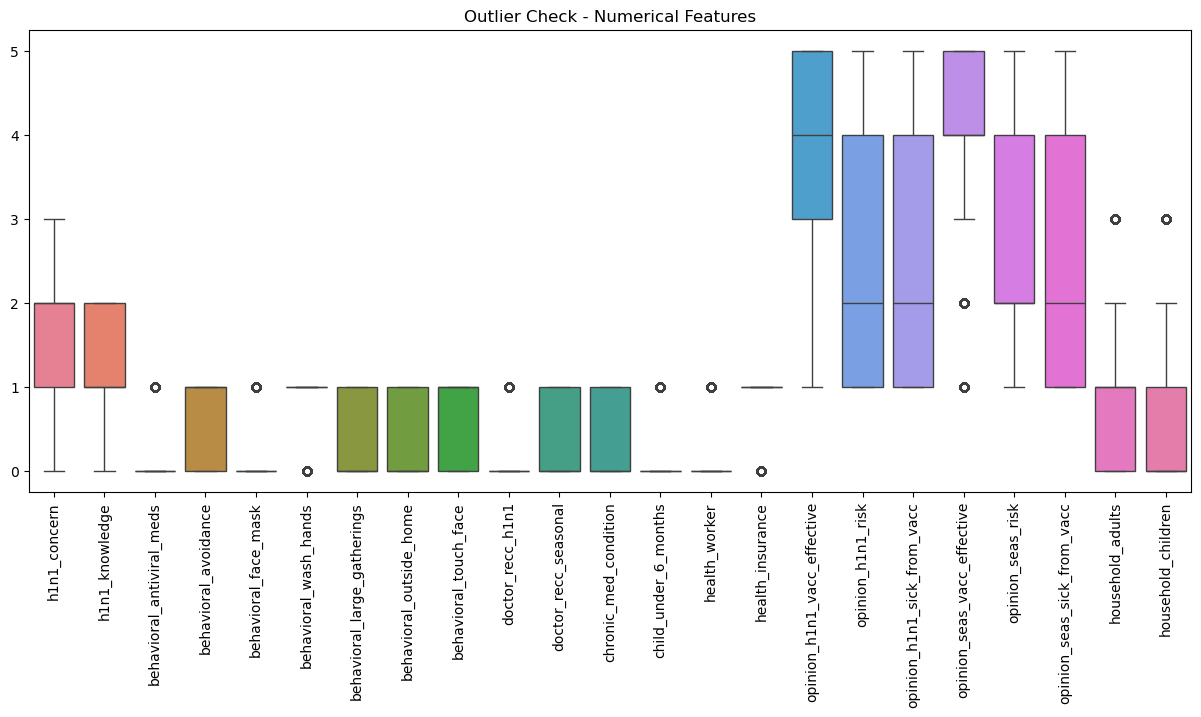

In [141]:
plt.figure(figsize=(15,6))
sns.boxplot(data=new_X_train[numerical_columns])
plt.xticks(rotation=90)
plt.title("Outlier Check - Numerical Features")
plt.show()

The boxplots reveal the presence of some outliers across numerical features, but they are not overly extreme or widespread. These values are retained as they may represent genuine variations rather than errors and are unlikely to significantly distort the models.

### EXPLORATORY DATA ANALYSIS- PART 2

#### 1. UNIVARIATE ANALYSIS

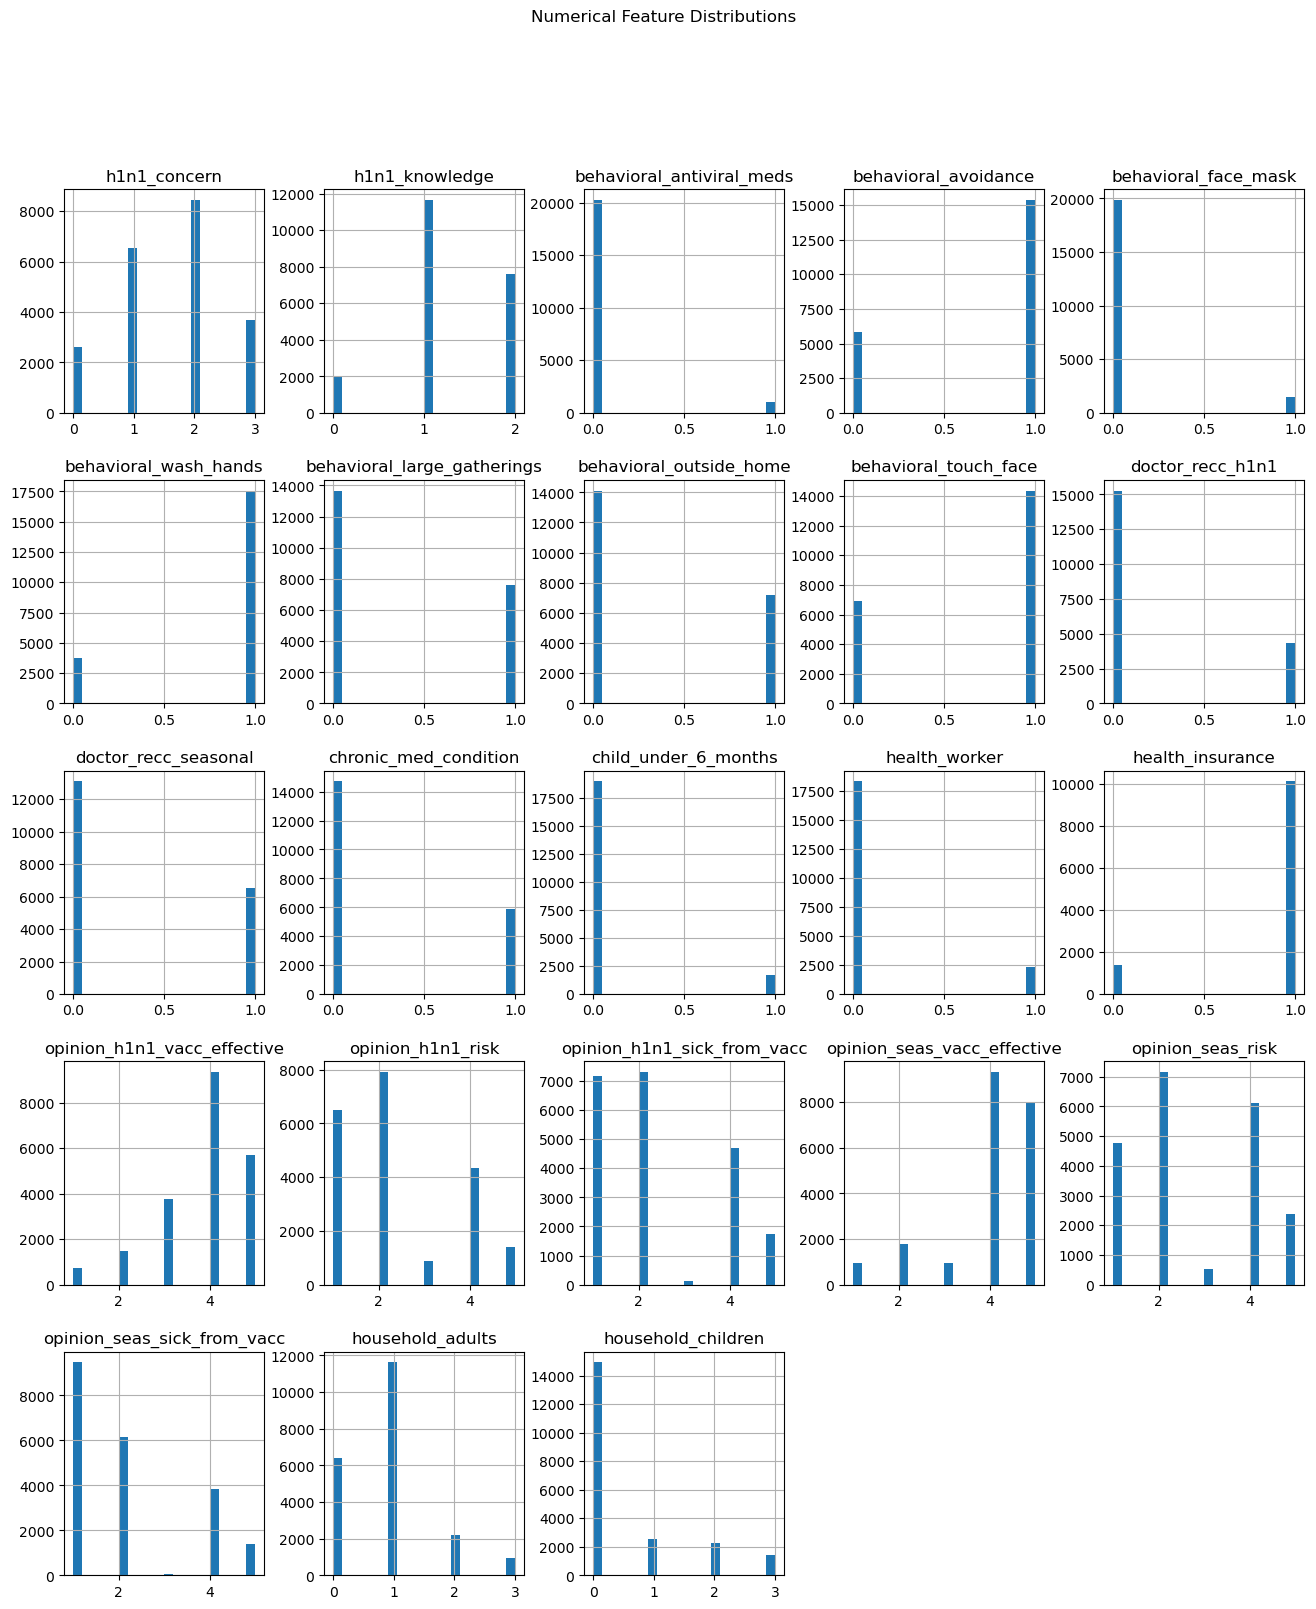

In [162]:
#NUMERICAL FEATURES
new_X_train[numerical_columns].hist(figsize=(16,18), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

In [148]:
#CATEGORICAL FEATURES
for col in categorical_columns:
    print(f"\n{col}")
    print(new_X_train[col].value_counts(normalize=True).head())


age_group
age_group
65+ Years        0.255277
55 - 64 Years    0.208799
18 - 34 Years    0.197145
45 - 54 Years    0.195834
35 - 44 Years    0.142944
Name: proportion, dtype: float64

education
education
College Graduate    0.398370
Some College        0.279941
12 Years            0.229051
< 12 Years          0.092638
Name: proportion, dtype: float64

race
race
White                0.794477
Black                0.077510
Hispanic             0.066136
Other or Multiple    0.061877
Name: proportion, dtype: float64

sex
sex
Female    0.596677
Male      0.403323
Name: proportion, dtype: float64

income_poverty
income_poverty
<= $75,000, Above Poverty    0.577055
> $75,000                    0.303905
Below Poverty                0.119041
Name: proportion, dtype: float64

marital_status
marital_status
Married        0.537417
Not Married    0.462583
Name: proportion, dtype: float64

rent_or_own
rent_or_own
Own     0.760602
Rent    0.239398
Name: proportion, dtype: float64

employment_status
e

The univariate analysis shows that several numerical features are skewed, while categorical variables are often imbalanced with dominant categories. This highlights the need for proper preprocessing before modeling.

#### 2. BIVARIATE ANALYSIS- TARGET VS FEATURES
a) Numerical vs Target

In [149]:
for col in categorical_columns:
    cross_tab = pd.crosstab(new_X_train[col], y_train['h1n1_vaccine'], normalize='index')
    print(f"\n{col}")
    print(cross_tab.head())


age_group
h1n1_vaccine          0         1
age_group                        
18 - 34 Years  0.811491  0.188509
35 - 44 Years  0.802554  0.197446
45 - 54 Years  0.803537  0.196463
55 - 64 Years  0.759247  0.240753
65+ Years      0.770627  0.229373

education
h1n1_vaccine             0         1
education                           
12 Years          0.816437  0.183563
< 12 Years        0.837867  0.162133
College Graduate  0.754062  0.245938
Some College      0.788387  0.211613

race
h1n1_vaccine              0         1
race                                 
Black              0.847826  0.152174
Hispanic           0.799009  0.200991
Other or Multiple  0.788956  0.211044
White              0.780311  0.219689

sex
h1n1_vaccine         0         1
sex                             
Female        0.781064  0.218936
Male          0.796565  0.203435

income_poverty
h1n1_vaccine                      0         1
income_poverty                               
<= $75,000, Above Poverty  0.794195  0.

b) Categorical vs Target

In [150]:
for col in categorical_columns:
    cross_tab = pd.crosstab(new_X_train[col], y_train['h1n1_vaccine'], normalize='index')
    print(f"\n{col}")
    print(cross_tab.head())


age_group
h1n1_vaccine          0         1
age_group                        
18 - 34 Years  0.811491  0.188509
35 - 44 Years  0.802554  0.197446
45 - 54 Years  0.803537  0.196463
55 - 64 Years  0.759247  0.240753
65+ Years      0.770627  0.229373

education
h1n1_vaccine             0         1
education                           
12 Years          0.816437  0.183563
< 12 Years        0.837867  0.162133
College Graduate  0.754062  0.245938
Some College      0.788387  0.211613

race
h1n1_vaccine              0         1
race                                 
Black              0.847826  0.152174
Hispanic           0.799009  0.200991
Other or Multiple  0.788956  0.211044
White              0.780311  0.219689

sex
h1n1_vaccine         0         1
sex                             
Female        0.781064  0.218936
Male          0.796565  0.203435

income_poverty
h1n1_vaccine                      0         1
income_poverty                               
<= $75,000, Above Poverty  0.794195  0.

The bivariate analysis indicates clear relationships between features and the target variables, suggesting that both demographic and behavioral factors influence vaccination outcomes and will be useful for prediction.

## PRE-PROCESSING 

### ENCODING CATEGORICAL COLUMNS

In [165]:
#ENCODING X_TRAIN CATEGORICAL COLUMNS
categorical_columns = new_X_train.select_dtypes(include=['object']).columns
X_train_categorical = X_train_clean[categorical_columns].copy()

ohe = OneHotEncoder(sparse_output=False)

ohe.fit(X_train_categorical)
X_train_ohe = pd.DataFrame(ohe.transform(X_train_categorical),
                                index = X_train_clean.index,
                                columns = np.hstack(ohe.categories_))
X_train_ohe




,18 - 34 Years,35 - 44 Years,45 - 54 Years,55 - 64 Years,65+ Years,12 Years,< 12 Years,College Graduate,Some College,Black,...,Employed,Not in Labor Force,Unemployed,"MSA, Not Principle City","MSA, Principle City",Non-MSA,Both Vaccines,H1N1 Only,Neither Vaccine,Seasonal Only
24706,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5393,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
20898,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3429,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
8731,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5390,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
860,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
15795,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [166]:
#ENCODING X_TEST CATEGORICAL COLUMNS
categorical_columns = new_X_test.select_dtypes(include=['object']).columns
X_test_categorical = X_test_clean[categorical_columns].copy()

X_test_ohe = pd.DataFrame(
    ohe.transform(X_test_categorical),        
    index=X_test_clean.index,
    columns=np.hstack(ohe.categories_)        
)
X_test_ohe


,18 - 34 Years,35 - 44 Years,45 - 54 Years,55 - 64 Years,65+ Years,12 Years,< 12 Years,College Graduate,Some College,Black,...,Employed,Not in Labor Force,Unemployed,"MSA, Not Principle City","MSA, Principle City",Non-MSA,Both Vaccines,H1N1 Only,Neither Vaccine,Seasonal Only
15772,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9407,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
16515,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
23353,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
10008,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25132,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
20086,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5045,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
6340,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [145]:
new_merged_dataset

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine,vaccine_group
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0,Neither Vaccine
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1,Seasonal Only
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0,Neither Vaccine
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1,Seasonal Only
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0,Neither Vaccine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN,0,0,Neither Vaccine
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea,0,0,Neither Vaccine
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN,0,1,Seasonal Only
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg,0,0,Neither Vaccine


#### CONCATINATION

In [170]:
# FOR X_TRAIN
Final_X_train = pd.concat(
    [X_train_clean[numerical_columns], X_train_ohe],
    axis=1
)

In [174]:
#FOR X_TEST
Final_X_test = pd.concat(
    [X_test_clean[numerical_columns], X_test_ohe], axis=1
)